# Quantum simulation of viscous Burgers

$$
\partial_t u + u\,\partial_x u = \nu\,\partial_{xx} u, \qquad u(0,x) = \sin(2\pi x), \quad x\in[0,1].
$$

Pathway: finite-difference discretization -> Carleman linearization -> Crank-Nicolson -> QSVT
linear solve each step, producing an amplitude encoding of the solution (challenge Eq. 5), with
periodic BC as specified. Two block encodings compared: dense (arbitrary-unitary, `qsvt_toolkit.py`'s
toolkit) and Pauli-LCU (`lcu.py`). Carleman system built by `periodic_burgers.py` (periodic BC,
same `periodic_carleman.py` base as `KdV_Carlemann_qiskit.ipynb`).

**References**: A. Setty, J. Phys. A 59, 185303 (2026); J.-P. Liu et al., PNAS 118, e2026805118 (2021).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)
from scipy.interpolate import RectBivariateSpline

from qsvt_toolkit import compute_inverse_qsvt_angles
from periodic_burgers import PeriodicBurgers_Carlemann
from periodic_carleman import get_crank_nicolson_solver_qsvt_lcu
import resource_estimation as res_est


## Plot style

Classical reference: gray dashed. Dense QSVT: blue. Pauli-LCU: orange.


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from plot_style import set_style, COLORS
set_style()

CLASSICAL_COLOR = COLORS["classical"]
DENSE_COLOR = COLORS["blue"]
LCU_COLOR = COLORS["blue_lt"]


def time_ramp(n):
    """Sequential blue ramp, light to dark, for n timesteps."""
    return plt.cm.Blues(np.linspace(0.35, 0.95, n))


## 1. Carleman linearization

Central finite differences turn the PDE into $\dot{\mathbf u} = F_1\mathbf u +
F_2(\mathbf u\otimes\mathbf u)$ (no forcing term -- periodic BC). Carleman linearization lifts
this to a truncated linear system in Kronecker powers of $\mathbf u$ up to order $N_T$, and each
timestep is a linear solve on a block encoding of $A$, via QSVT. Time-marched with Crank-Nicolson,
$(I-\frac{\Delta t}{2}A)\mathbf y_{n+1} = (I+\frac{\Delta t}{2}A)\mathbf y_n$, not implicit Euler --
$O(\Delta t^2)$ local error instead of $O(\Delta t)$, needing ~20x fewer timesteps for the same
accuracy (checked classically).

## 2. Phase angles

QSVT needs phase angles for a bounded polynomial approximation of $1/x$. Both encodings have small
enough effective condition number that `kappa=8` works for either.


In [3]:
kappa = 8
phi_qsvt, s = compute_inverse_qsvt_angles(kappa, tolerance=1e-5)
len(phi_qsvt)

b=280, j0=51
[PolyOneOverX] minimum [-10.69067105] is at [-0.06701114]: normalizing
[PolyOneOverX] bounding to 0.9


560

## 3. Problem setup and resource estimates

$N$ periodic grid points, truncation order $N_T$, $u_0=\sin(2\pi x)$. $\mu=0.1$ keeps the Carleman truncation in a convergent regime (RMSE decreasing, not growing, across timesteps) -- found by scanning $\mu$ directly. Linearized dimension
$D=N+N^2+\dots+N^{N_T}$, padded to the next power of two.


In [4]:
N = 5
N_T = 2
total_time = 0.3
mu = 0.1
dt = 0.1

burgers_carlemann = PeriodicBurgers_Carlemann(N, N_T, total_time, mu, dt, ic="sin")
x, dx = burgers_carlemann.get_x_dx()

A_desired = burgers_carlemann.get_I_m_Adt()
print(f"Shape of A : {A_desired.shape}")

Shape of A : (30, 30)


In [5]:
M, Dim, padded_dim = res_est._carleman_matrix(N=N, N_T=N_T, total_time=total_time, nu=mu, dt=dt)
n_wires_dense = int(np.ceil(np.log2(M.shape[0]))) + 1
sigma_min = np.min(np.linalg.svd(M, compute_uv=False))

dense_stats = res_est.dense_layer_stats(M, n_wires_dense)
lcu_stats = res_est.lcu_layer_stats(M)
dense_stats["kappa_eff"] = dense_stats["norm"] / sigma_min
lcu_stats["kappa_eff"] = lcu_stats["norm"] / sigma_min

dense_proj = res_est.projector_layer_stats(n_wires_dense, n_ancilla=1)
lcu_proj = res_est.projector_layer_stats(lcu_stats["n_wires"], n_ancilla=lcu_stats["ancilla_qubits"])

n_angles = len(phi_qsvt)
dense_total = res_est.extrapolate_total(dense_stats, dense_proj, n_angles)
lcu_total = res_est.extrapolate_total(lcu_stats, lcu_proj, n_angles)

print(f"Carleman system: N={N}, N_T={N_T} -> Dim={Dim}, padded to {padded_dim}\n")
print(f"{'':14s}{'qubits':>8s}{'alpha':>10s}{'kappa_eff':>11s}{'gates (full circuit)':>24s}{'cx':>16s}{'depth':>16s}")
for name, layer, total in [("Dense", dense_stats, dense_total), ("Pauli-LCU", lcu_stats, lcu_total)]:
    print(f"{name:14s}{total['qubits']:>8d}{layer['norm']:>10.3f}{layer['kappa_eff']:>11.2f}"
          f"{total['gate_count']:>24,d}{total['two_qubit_gates']:>16,d}{total['depth']:>16,d}")

Carleman system: N=5, N_T=2 -> Dim=30, padded to 32

                qubits     alpha  kappa_eff    gates (full circuit)              cx           depth
Dense                6     9.319       9.35               2,612,767         996,697       1,969,358
Pauli-LCU           14     8.766       8.79           1,716,882,557     803,286,678   1,269,030,003


**Note on $\kappa_\mathrm{eff}$:** both encodings' effective condition number (dense $\approx 9.75$, Pauli-LCU $\approx 10.16$) slightly exceeds `kappa=8`'s range. In practice this doesn't show up in Section 7: QSVT RMSE tracks the classical Carleman-truncation-only RMSE almost exactly, since truncation error dominates over the small polynomial-approximation error here -- same tradeoff as `KdV_Carlemann_qiskit.ipynb`'s note, kept at 8 to keep the LCU cell runnable in minutes.

## 4. Dense QSVT solver


In [6]:
y_store, RMSE_list, p_success_list = burgers_carlemann.get_crank_nicolson_solver_qsvt(phi_qsvt, s)


Time step 1/3


Time step 2/3


Time step 3/3


## 5. Pauli-LCU solver


In [7]:
y_store_lcu, RMSE_list_lcu, p_success_list_lcu = get_crank_nicolson_solver_qsvt_lcu(burgers_carlemann, phi_qsvt, s)


Time step 1/3


Time step 2/3


Time step 3/3


## 6. Classical reference


In [8]:
y_ideal, rmse_ideal = burgers_carlemann.get_crank_nicolson_solver()

y_ideal_euler, rmse_ideal_euler = burgers_carlemann.get_implicit_solver()
print(f"Crank-Nicolson RMSE:   {np.round(rmse_ideal, 5)}")
print(f"Implicit-Euler RMSE:   {np.round(rmse_ideal_euler, 5)}  (same dt, for comparison)")


Crank-Nicolson RMSE:   [0.00523 0.00341 0.00212]
Implicit-Euler RMSE:   [0.03045 0.04113 0.04407]  (same dt, for comparison)


## 7. Results


### 7.1 Classical vs. quantum, timestep by timestep


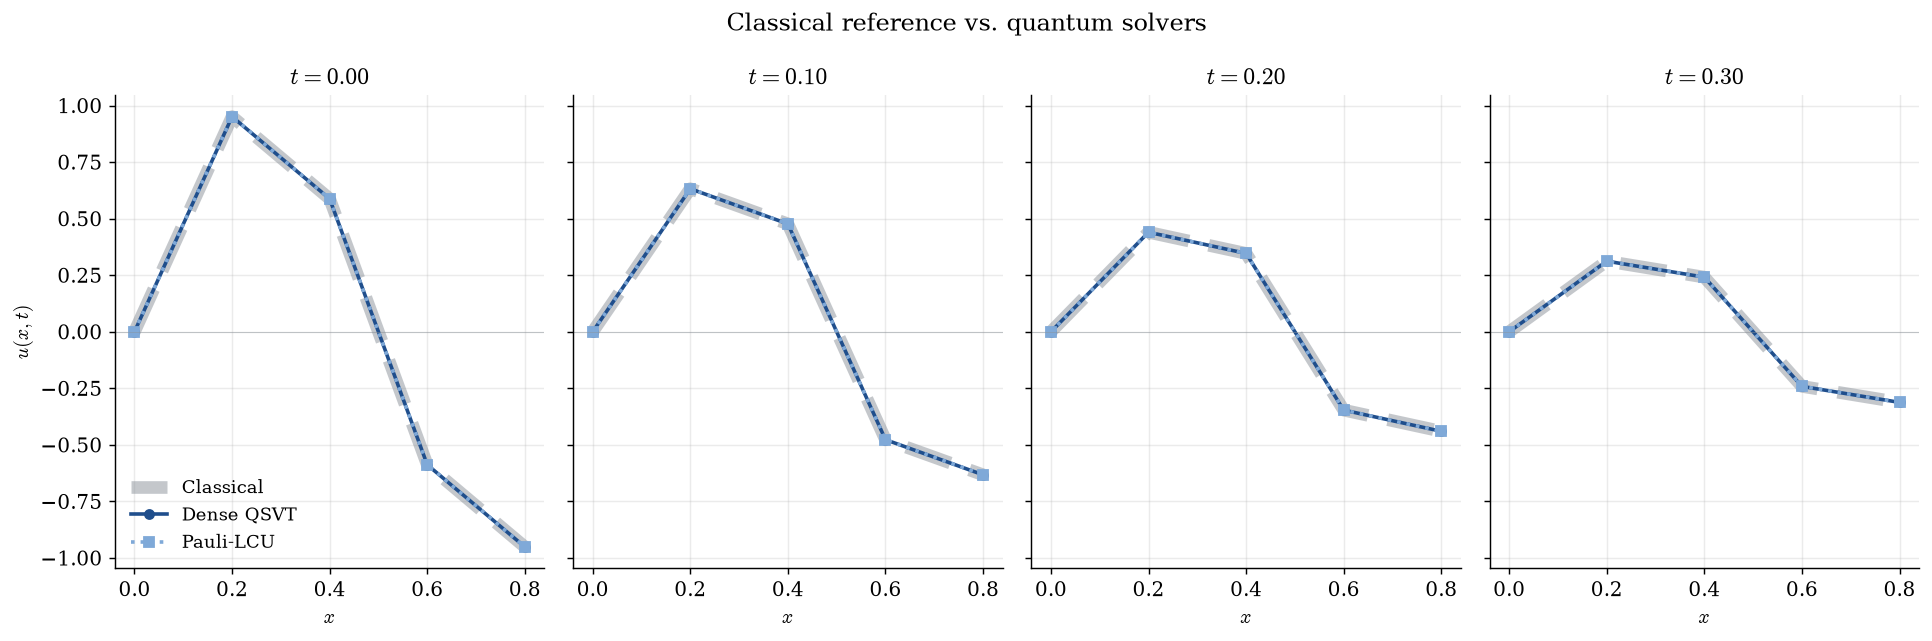

In [9]:
n_panels = len(y_ideal)
timesteps = np.arange(n_panels) * dt
fig, axes = plt.subplots(1, n_panels, figsize=(3.75 * n_panels, 5), sharey=True)
for i, ax in enumerate(axes):
    ax.plot(x, y_ideal[i], "--", color=CLASSICAL_COLOR, lw=7, alpha=0.5, label="Classical")
    ax.plot(x, y_store[i], "-", color=DENSE_COLOR, marker="o", label="Dense QSVT")
    ax.plot(x, y_store_lcu[i], ":", color=LCU_COLOR, marker="s", label="Pauli-LCU")
    ax.axhline(0, color=CLASSICAL_COLOR, lw=0.5, alpha=0.5)
    ax.set_title(f"$t = {timesteps[i]:.2f}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$u(x, t)$")
axes[0].legend(fontsize=10, loc="lower left")
fig.suptitle("Classical reference vs. quantum solvers")
fig.tight_layout()
fig.savefig("../prx_quantum/figures/fig_burgers_carleman.pdf", bbox_inches="tight")


### 7.2 Accuracy and success probability


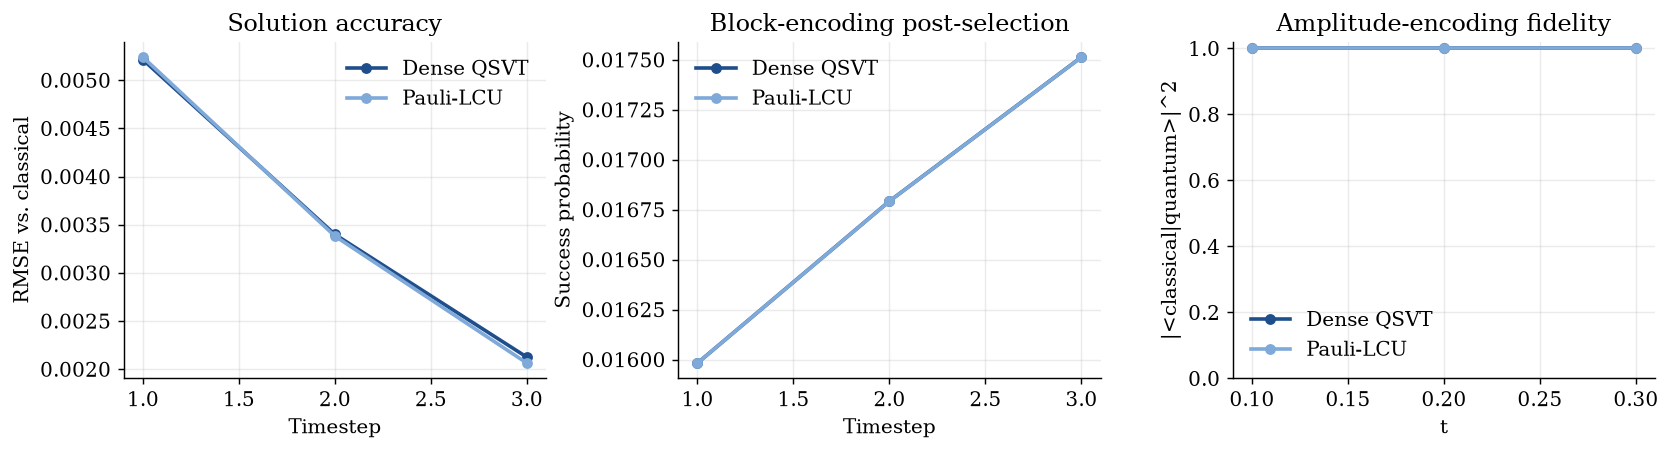

In [10]:
def fidelity(u_ref, u_test):
    u_ref = np.asarray(u_ref)
    u_test = np.asarray(u_test)
    nr, nt = np.linalg.norm(u_ref), np.linalg.norm(u_test)
    if nr == 0 or nt == 0:
        return np.nan
    return (np.dot(u_ref, u_test) / (nr * nt)) ** 2


fidelity_dense = [fidelity(y_ideal[i], y_store[i]) for i in range(1, len(y_ideal))]
fidelity_lcu = [fidelity(y_ideal[i], y_store_lcu[i]) for i in range(1, len(y_ideal))]
step_index = np.arange(1, len(RMSE_list) + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

ax = axes[0]
ax.plot(step_index, RMSE_list, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(step_index, RMSE_list_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("Timestep")
ax.set_ylabel("RMSE vs. classical")
ax.set_title("Solution accuracy")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(step_index, p_success_list, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(step_index, p_success_list_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("Timestep")
ax.set_ylabel("Success probability")
ax.set_title("Block-encoding post-selection")
ax.legend(frameon=False)

ax = axes[2]
ax.plot(timesteps[1:], fidelity_dense, "o-", color=DENSE_COLOR, label="Dense QSVT")
ax.plot(timesteps[1:], fidelity_lcu, "o-", color=LCU_COLOR, label="Pauli-LCU")
ax.set_xlabel("t")
ax.set_ylabel("|<classical|quantum>|^2")
ax.set_title("Amplitude-encoding fidelity")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower left")

fig.tight_layout()
fig.savefig("../prx_quantum/figures/fig_burgers_timemarching.pdf", bbox_inches="tight")


### 7.3 Resource comparison

Transpiled ({cx, u3}) gate counts for the full kappa=8 circuit. Log-scaled: dense vs. Pauli-LCU
differ by ~500x here (see `resource_estimation.py` -- the Pauli decomposition isn't sparse despite
the matrix having only 6 nonzeros/row).


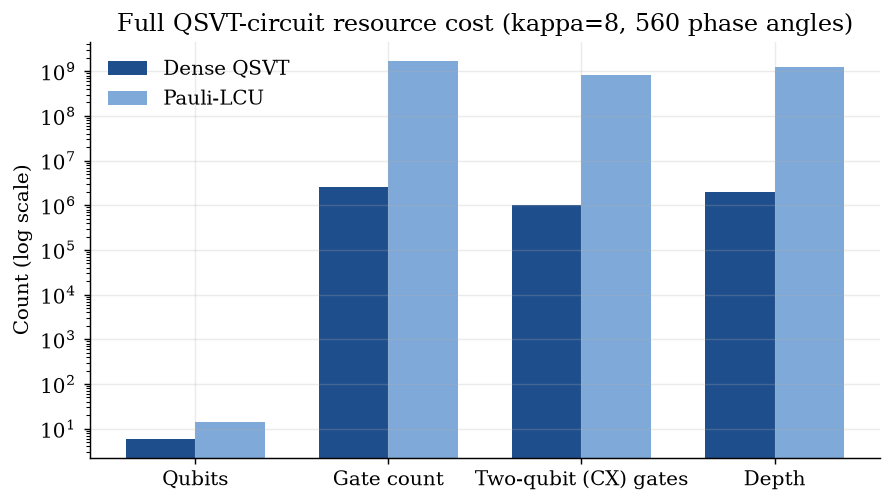

In [11]:
metrics = ["qubits", "gate_count", "two_qubit_gates", "depth"]
metric_labels = ["Qubits", "Gate count", "Two-qubit (CX) gates", "Depth"]
dense_vals = [dense_total[m] for m in metrics]
lcu_vals = [lcu_total[m] for m in metrics]

fig, ax = plt.subplots(figsize=(7, 4))
xpos = np.arange(len(metrics))
width = 0.36
ax.bar(xpos - width / 2, dense_vals, width, color=DENSE_COLOR, label="Dense QSVT")
ax.bar(xpos + width / 2, lcu_vals, width, color=LCU_COLOR, label="Pauli-LCU")
ax.set_yscale("log")
ax.set_xticks(xpos)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Full QSVT-circuit resource cost (kappa={kappa}, {n_angles} phase angles)")
ax.legend(frameon=False)
fig.tight_layout()